### Aug 2022: END SEMESTER ASSESSMENT (ESA)
## M TECH DATA SCIENCE AND MACHINE LEARNING_ SEMESTER I
### UE20CS902 – Statistical Methods for Decision Making
  

In [16]:
# import 'pandas'
import pandas as pd

# import 'numpy'
import numpy as np

# import subpackage of matplotlib
import matplotlib.pyplot as plt

# import 'seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# import statsmodels
import statsmodels.api as sm

# import 'stats' package from scipy library
import scipy.stats as stats

# import statistics to perform statistical computations
import statistics

# to test the normality
from scipy.stats import shapiro

# import a library to perform Z-test
from statsmodels.stats import weightstats as stests

# import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# import the functions to perform Chi-square tests
from scipy.stats import chi2_contingency
from scipy.stats import chi2
from scipy.stats import chisquare

# Section B

#### 3a) Jim is a real estate agent who sells large commercial buildings, Because his commission is so large on a single sale,   he does not need to sell many buildings to make a good living. History shows that Jim has a record of selling an average of eight large commercial buildings every 275 days.  In a 60-day period, what is the probability that Jim will make

- No sales?
- One sale?
- Two or more sales?
- In a 90-day period, what is the probability that Jim will make no sales? (1+1+1+2)


In [17]:
import scipy.stats as stats

# Given data
annual_sales_rate = 8  # sales
annual_days = 275    # days

# Calculate the average sales rate per day
mean_sales_per_day = annual_sales_rate / annual_days

# --- For a 60-day period ---
# Average number of sales in 60 days (lambda for Poisson distribution)
lambda_60_days = mean_sales_per_day * 60
print(f"Average sales in 60 days (λ): {lambda_60_days:.4f}\n")

# Probability of No sales?
prob_no_sales_60 = stats.poisson.pmf(0, lambda_60_days)
print(f"Probability of no sales in 60 days: {prob_no_sales_60:.4f}")

# Probability of One sale?
prob_one_sale_60 = stats.poisson.pmf(1, lambda_60_days)
print(f"Probability of one sale in 60 days: {prob_one_sale_60:.4f}")

# Probability of Two or more sales?
# P(X >= 2) = 1 - P(X < 2) = 1 - (P(X=0) + P(X=1))
prob_two_or_more_sales_60 = 1 - (prob_no_sales_60 + prob_one_sale_60)
print(f"Probability of two or more sales in 60 days: {prob_two_or_more_sales_60:.4f}")

# --- For a 90-day period ---
# Average number of sales in 90 days (lambda for Poisson distribution)
lambda_90_days = mean_sales_per_day * 90
print(f"\nAverage sales in 90 days (λ): {lambda_90_days:.4f}\n")

# Probability that Jim will make no sales?
prob_no_sales_90 = stats.poisson.pmf(0, lambda_90_days)
print(f"Probability of no sales in 90 days: {prob_no_sales_90:.4f}")

Average sales in 60 days (λ): 1.7455

Probability of no sales in 60 days: 0.1746
Probability of one sale in 60 days: 0.3047
Probability of two or more sales in 60 days: 0.5207

Average sales in 90 days (λ): 2.6182

Probability of no sales in 90 days: 0.0729


#### 3b) The compressive strength of samples of cement can be modeled by a normal distribution with a mean of 6000 kilograms per square centimeter and a standard deviation of 100 kilograms per square centimeter.

- i. What is the probability that a sample’s strength is less than 6250 Kg/cm2 ( 2mark)
- ii. What is the probability that a sample’s strength is between 5800 and 5900 Kg/cm2(2 mark)
- iii. What strength is exceeded by 95% of the samples (2 mark)k


For part 3b, we are dealing with a normal distribution. We'll use the `scipy.stats.norm` functions to calculate the required probabilities and the quantile.

**Given:**
*   Mean (μ) = 6000 Kg/cm²
*   Standard Deviation (σ) = 100 Kg/cm²

In [18]:
# Given parameters for the normal distribution
mean = 6000
std_dev = 100

# i. Probability that a sample's strength is less than 6250 Kg/cm2
prob_less_than_6250 = stats.norm.cdf(6250, loc=mean, scale=std_dev)
print(f"i. Probability that a sample's strength is less than 6250 Kg/cm2: {prob_less_than_6250:.4f}")

# ii. Probability that a sample's strength is between 5800 and 5900 Kg/cm2
prob_less_than_5900 = stats.norm.cdf(5900, loc=mean, scale=std_dev)
prob_less_than_5800 = stats.norm.cdf(5800, loc=mean, scale=std_dev)
prob_between_5800_and_5900 = prob_less_than_5900 - prob_less_than_5800
print(f"ii. Probability that a sample's strength is between 5800 and 5900 Kg/cm2: {prob_between_5800_and_5900:.4f}")

# iii. What strength is exceeded by 95% of the samples?
# This means we are looking for the value x such that P(X > x) = 0.95
# Equivalently, P(X <= x) = 0.05 (the 5th percentile)
strength_exceeded_by_95_percent = stats.norm.ppf(0.05, loc=mean, scale=std_dev)
print(f"iii. Strength exceeded by 95% of the samples: {strength_exceeded_by_95_percent:.2f} Kg/cm2")

i. Probability that a sample's strength is less than 6250 Kg/cm2: 0.9938
ii. Probability that a sample's strength is between 5800 and 5900 Kg/cm2: 0.1359
iii. Strength exceeded by 95% of the samples: 5835.51 Kg/cm2


#### 3c) The production manager at the Yen Sewing Factory claims that on average the diameter of a class 14M bobbin is less than 18 mm. The previous study shows that the standard deviation is 1.7 mm. Consider a sample of 40 class 14M bobbins from a normally distributed population with sample mean diameter as 17.5 mm. Plot the acceptance and rejection regions to test the claim of the production manager with 99% confidence.
    i. State the null hypothesis and the alternate hypothesis. (1 mark)
    ii. Which test is to be performed. (1 mark)
    iii. Compute test statistics, p value. (3 marks)
    iv. At the 0.01 significance level, can we conclude that water consumption has increased? (1 mark)



#### Plot the acceptance and rejection regions and conclude.

We will plot the standard normal distribution, mark the critical Z-value for a 99% confidence (0.01 significance level) left-tailed test, and show where our calculated Z-statistic falls. We will then compare the p-value with the significance level.

The null and alternative hypothesis is:

H<sub>0</sub>: $\mu \geq 18 $<br>
H<sub>1</sub>: $\mu < 18 $

Let us plot the acceptance and rejection region for a left-tailed test with 99% confidence.

Critical Z-value at α=0.01: -2.3263
Calculated Z-test statistic: -1.8602
Calculated P-value: 0.0314



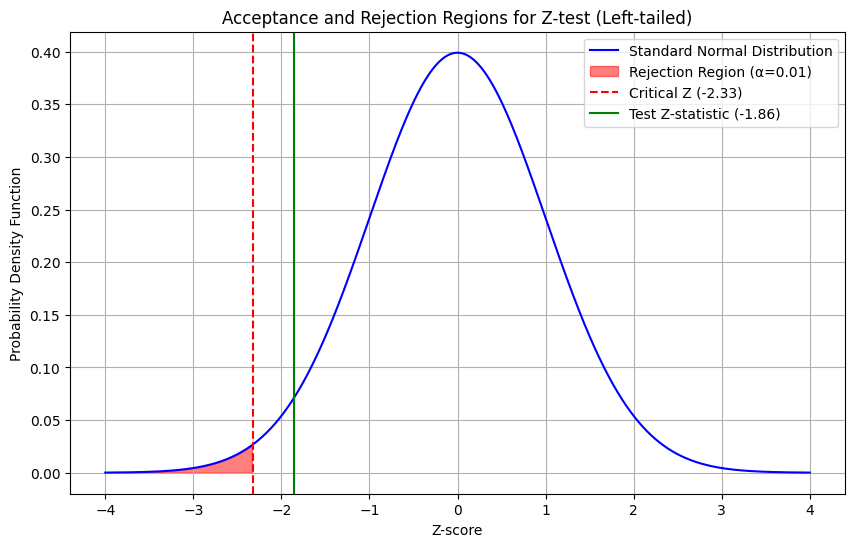


--- Conclusion ---
Since the p-value (0.0314) is greater than or equal to the significance level (0.01), we fail to reject the null hypothesis.
Therefore, there is not enough evidence to support the production manager's claim that the average diameter of a class 14M bobbin is less than 18 mm.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Variables definitions (added to fix NameError) ---
# Given data from problem 3c
population_mean_hypothesized = 18 # μ0 = 18 mm
population_std_dev = 1.7          # σ = 1.7 mm
sample_size = 40                  # n = 40
sample_mean = 17.5                # x̄ = 17.5 mm
significance_level = 0.01         # α = 0.01 (for 99% confidence)

# Calculate the Z-test statistic
z_statistic = (sample_mean - population_mean_hypothesized) / (population_std_dev / (sample_size**0.5))

# Calculate the p-value for a left-tailed test
p_value = norm.cdf(z_statistic)
# --- End of added definitions ---


# Calculate the critical Z-value for a left-tailed test at alpha = 0.01
critical_z = norm.ppf(significance_level)
print(f"Critical Z-value at α={significance_level}: {critical_z:.4f}")
print(f"Calculated Z-test statistic: {z_statistic:.4f}")
print(f"Calculated P-value: {p_value:.4f}\n")

# Generate x values for the standard normal distribution
x = np.linspace(-4, 4, 1000)

# Plot the standard normal distribution
plt.figure(figsize=(10, 6))
plt.plot(x, norm.pdf(x), color='blue', label='Standard Normal Distribution')

# Shade the rejection region
x_rejection = x[x < critical_z]
plt.fill_between(x_rejection, 0, norm.pdf(x_rejection), color='red', alpha=0.5, label='Rejection Region (α=0.01)')

# Plot the critical Z-value
plt.axvline(critical_z, color='red', linestyle='--', label=f'Critical Z ({critical_z:.2f})')

# Plot the calculated Z-statistic
plt.axvline(z_statistic, color='green', linestyle='-', label=f'Test Z-statistic ({z_statistic:.2f})')

plt.title('Acceptance and Rejection Regions for Z-test (Left-tailed)')
plt.xlabel('Z-score')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion
print("\n--- Conclusion ---")
if p_value < significance_level:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({significance_level}), we reject the null hypothesis.")
    print("Therefore, there is sufficient evidence to support the production manager's claim that the average diameter of a class 14M bobbin is less than 18 mm.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({significance_level}), we fail to reject the null hypothesis.")
    print("Therefore, there is not enough evidence to support the production manager's claim that the average diameter of a class 14M bobbin is less than 18 mm.")

#### 3d) Two catalysts are being analyzed to determine how they affect the mean yield of a chemical process. Specifically, catalysts 1 is currently in use, but catalyst 2 is acceptable. Since catalyst is cheaper, it should be adopted, providing it does not change the process yield. A test is run in the pilot plant and results in the data shown table. Is there any difference in mean yields for an α =.05 and assume equal variances

```
Number	     1	     2	   3	   4	    5	    6	    7	   8
Catlayst1	91.50	94.18	92.18	95.39	91.79	89.07	94.72   89.21
Catalyst2	89.19	90.95	90.46	93.21	97.19	97.04	91.07   92.75

```

- i)	State the hypothesis and type of test to be used                    2 marks
- ii)	Test the hypothesis and conclude                                    4 marks

In [20]:
# Data for Catalyst 1 and Catalyst 2
catalyst1 = [91.50, 94.18, 92.18, 95.39, 91.79, 89.07, 94.72, 89.21]
catalyst2 = [89.19, 90.95, 90.46, 93.21, 97.19, 97.04, 91.07, 92.75]

# Convert to numpy arrays for easier manipulation if needed
catalyst1 = np.array(catalyst1); catalyst2 = np.array(catalyst2)

print("Catalyst 1 Data:", catalyst1)
print("Catalyst 2 Data:", catalyst2)

print("\n--- Hypotheses and Test Type ---")
print("Null Hypothesis (H0): There is no difference in the mean yields of Catalyst 1 and Catalyst 2. (μ1 = μ2)")
print("Alternate Hypothesis (H1): There is a significant difference in the mean yields of Catalyst 1 and Catalyst 2. (μ1 ≠ μ2)")
print("This is a two-tailed test.")
print("Type of Test: Two-Sample Independent t-test (assuming equal variances, i.e., pooled t-test).")

# Perform a two-sample independent t-test with equal variances
t_statistic, p_value = stats.ttest_ind(catalyst1, catalyst2, equal_var=True)

significance_level = 0.05 # α = 0.05

print(f"\n--- Test Results ---")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

print("\n--- Conclusion ---")
if p_value < significance_level:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({significance_level}), we reject the null hypothesis.")
    print("There is a statistically significant difference in the mean yields between Catalyst 1 and Catalyst 2.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({significance_level}), we fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the mean yields between Catalyst 1 and Catalyst 2.")
    print("Given that Catalyst 2 is cheaper and there's no significant difference in yield, it should be adopted.")

Catalyst 1 Data: [91.5  94.18 92.18 95.39 91.79 89.07 94.72 89.21]
Catalyst 2 Data: [89.19 90.95 90.46 93.21 97.19 97.04 91.07 92.75]

--- Hypotheses and Test Type ---
Null Hypothesis (H0): There is no difference in the mean yields of Catalyst 1 and Catalyst 2. (μ1 = μ2)
Alternate Hypothesis (H1): There is a significant difference in the mean yields of Catalyst 1 and Catalyst 2. (μ1 ≠ μ2)
This is a two-tailed test.
Type of Test: Two-Sample Independent t-test (assuming equal variances, i.e., pooled t-test).

--- Test Results ---
T-statistic: -0.3536
P-value: 0.7289

--- Conclusion ---
Since the p-value (0.7289) is greater than or equal to the significance level (0.05), we fail to reject the null hypothesis.
There is no statistically significant difference in the mean yields between Catalyst 1 and Catalyst 2.
Given that Catalyst 2 is cheaper and there's no significant difference in yield, it should be adopted.


#### 3e) A multinational company had organized a presentation activity to test the soft skills of their 6 sales executives and then offered them a skill development course. After the completion of the course, the executives again appeared for the presentation and the scores before and after the course are recorded. Test the company's claim that the course was effective in developing soft skills with 95% confidence using the p-value technique.

    Consider the scores given in the file `paired_data.xlsx`
    please consider the first two attributes

1. Check if the attributes are normally distributed (2 marks)
2. State the null hypothesis and alternate hypothesis (1 mark)
3. Test the hypothesis and conclude. (3 marks)



In [21]:
# Load the paired data from the Excel file
df_paired = pd.read_excel('/content/sample_data/paired_data.xlsx')
#display(df_paired.head())

print("\n#### 1. Check if the attributes are normally distributed")
# Shapiro-Wilk Test for 'Before_Course'
stat_before, p_before = shapiro(df_paired['before_score'])
print(f"Shapiro-Wilk Test for 'before_score': Statistic={stat_before:.3f}, p-value={p_before:.3f}")

# Shapiro-Wilk Test for 'After_Course'
stat_after, p_after = shapiro(df_paired['after_score'])
print(f"Shapiro-Wilk Test for 'after_score': Statistic={stat_after:.3f}, p-value={p_after:.3f}")

alpha_normality = 0.05

if p_before > alpha_normality:
    print("'before_score' appears to be normally distributed (fail to reject H0)")
else:
    print("'before_score' does not appear to be normally distributed (reject H0)")

if p_after > alpha_normality:
    print("'after_score' appears to be normally distributed (fail to reject H0)")
else:
    print("'after_score' does not appear to be normally distributed (reject H0)")

print("\n#### 2. State the null hypothesis and alternate hypothesis")
print("Since we are testing if the course was effective, we are looking for an increase in scores 'After_Course' compared to 'Before_Course'. This implies a one-tailed test.")
print("Let \u03bc_d be the mean difference in scores (After - Before).")
print("*   Null Hypothesis (H0): The skill development course was not effective, meaning the mean score after the course is less than or equal to the mean score before the course. (\u03bc_d \u2264 0)")
print("*   Alternate Hypothesis (H1): The skill development course was effective, meaning the mean score after the course is greater than the mean score before the course. (\u03bc_d > 0)")

print("\n#### 3. Test the hypothesis and conclude.")
# Perform a paired sample t-test
# We're testing if After_Course scores are significantly higher than Before_Course scores
# Therefore, it's a one-tailed test (After > Before)
# For scipy.stats.ttest_rel, if the alternative is 'greater', it means mean(a) > mean(b)
# So, we pass 'After_Course' as 'a' and 'Before_Course' as 'b'

t_statistic, p_value_two_tailed = stats.ttest_rel(df_paired['after_score'], df_paired['before_score'])

# For a one-tailed test (H1: After > Before), we divide the p-value by 2
p_value_one_tailed = p_value_two_tailed / 2

significance_level = 0.05 # For 95% confidence

print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed P-value: {p_value_one_tailed:.4f}")

print("\n--- Conclusion ---")
if t_statistic > 0 and p_value_one_tailed < significance_level:
    print(f"Since the one-tailed p-value ({p_value_one_tailed:.4f}) is less than the significance level ({significance_level}), we reject the null hypothesis.")
    print("There is sufficient evidence to conclude that the course was effective in developing soft skills.")
elif t_statistic <= 0 and p_value_one_tailed < significance_level:
    print(f"Although the p-value ({p_value_one_tailed:.4f}) is less than the significance level ({significance_level}), the t-statistic is not in the direction of the alternative hypothesis (t_statistic = {t_statistic:.4f}).")
    print("We fail to reject the null hypothesis. There is not enough evidence to conclude that the course was effective.")
else:
    print(f"Since the one-tailed p-value ({p_value_one_tailed:.4f}) is greater than or equal to the significance level ({significance_level}), we fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that the course was effective in developing soft skills.")


#### 1. Check if the attributes are normally distributed
Shapiro-Wilk Test for 'before_score': Statistic=0.998, p-value=1.000
Shapiro-Wilk Test for 'after_score': Statistic=0.903, p-value=0.392
'before_score' appears to be normally distributed (fail to reject H0)
'after_score' appears to be normally distributed (fail to reject H0)

#### 2. State the null hypothesis and alternate hypothesis
Since we are testing if the course was effective, we are looking for an increase in scores 'After_Course' compared to 'Before_Course'. This implies a one-tailed test.
Let μ_d be the mean difference in scores (After - Before).
*   Null Hypothesis (H0): The skill development course was not effective, meaning the mean score after the course is less than or equal to the mean score before the course. (μ_d ≤ 0)
*   Alternate Hypothesis (H1): The skill development course was effective, meaning the mean score after the course is greater than the mean score before the course. (μ_d > 0)

#### 3. Test the hypo

# Section C

### 4a) Consider the admission.xlsx file and answer the following questions


DATA DESCRIPTION:
The data set consists of complete educational details of students right from their schooling to MBA and previous work experience. Our main objective is to predict the Salary of the students based on the info available
ATTRIBUTES:

    SlNo - ID of the student
    Gender - Gender of Student
    Percent_SSC - Percentage of marks scored in SSC
    Board_SSC - Types of Boards in SSC
    Percent_HSC - Percentage of marks scored in HSC
    Board_HSC - Types of Boards in HSC
    Stream_HSC - Specialization in HSC
    Percent Degree - Percentage of marks scored in Degree
    Course_Degree - Different courses in degree
    Experience_Yrs - Work Experience of the Students
    Entrance_Test - Test which students give for MBA college Entrance
    Percentile_ET - Percentage of marks scored in Entrance_Test
    Percent_MBA - Percentage of marks scored in MBA
    Specialization_MBA - Specialization in MBA
    Marks Communication - Percentage of marks scored in Communication
    Marks_Projectwork - Percentage of marks scored in Project Work
    Placement - Whether Student got placed or not
    Salary - Salary of students


###### 4a.i)Provide a summary statistics of all the variables and explain which variables has high variability (3 mark) <br> List out the numerical and categorical features in the dataset (2 marks) <br>  (Total- 5marks)



In [22]:
df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### Summary Statistics of all variables:")
display(df.describe(include='all'))

print("\n#### Numerical and Categorical Features:")
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical Features:", numerical_cols)
print("Categorical Features:", categorical_cols)

print("\n#### Variables with High Variability (Coefficient of Variation):")
# Calculate coefficient of variation (CV) for numerical columns
# CV = (Standard Deviation / Mean) * 100
# We'll filter out columns where mean is zero to avoid division by zero

cv_data = {}
for col in numerical_cols:
    if df[col].mean() != 0 and df[col].std() != 0: # Ensure non-zero mean and std for meaningful CV
        cv = (df[col].std() / df[col].mean()) * 100
        cv_data[col] = cv

# Sort by CV in descending order
cv_series = pd.Series(cv_data).sort_values(ascending=False)
display(cv_series)

print("\nVariables with higher Coefficient of Variation (CV) have greater variability relative to their mean.")

#### Summary Statistics of all variables:


,SlNo,Gender,Percent_SSC,Board_SSC,Percent_HSC,Board_HSC,Stream_HSC,Percent_Degree,Course_Degree,Experience_Yrs,Entrance_Test,Percentile_ET,Percent_MBA,Specialization_MBA,Marks_Communication,Marks_Projectwork,Placement,Salary
count,638.000000,638,638.000000,638,638.000000,638,638,638.000000,638,638.000000,557,638.00000,638.000000,622,638.000000,638.000000,638,638.000000
unique,NaN,2,NaN,3,NaN,3,3,NaN,7,NaN,8,NaN,NaN,4,NaN,NaN,2,NaN
top,NaN,M,NaN,Others,NaN,Others,Commerce,NaN,Management,NaN,MAT,NaN,NaN,Marketing & Finance,NaN,NaN,Placed,NaN
freq,NaN,348,NaN,385,NaN,281,284,NaN,252,NaN,441,NaN,NaN,269,NaN,NaN,526,NaN
mean,319.500000,NaN,64.483511,NaN,63.825172,NaN,NaN,63.560846,NaN,0.545455,NaN,58.78290,62.610611,NaN,61.545768,66.082806,NaN,237541.692790
std,184.319017,NaN,10.966776,NaN,11.452802,NaN,NaN,10.311266,NaN,0.700058,NaN,26.18736,8.487143,NaN,11.640961,9.732895,NaN,145160.746448
min,1.000000,NaN,37.000000,NaN,38.000000,NaN,NaN,7.000000,NaN,0.000000,NaN,0.00000,38.000000,NaN,35.000000,37.000000,NaN,0.000000
25%,160.250000,NaN,56.000000,NaN,54.000000,NaN,NaN,56.095000,NaN,0.000000,NaN,51.00000,56.637500,NaN,53.000000,59.000000,NaN,162000.000000
50%,319.500000,NaN,64.600000,NaN,63.000000,NaN,NaN,63.450000,NaN,0.000000,NaN,64.00000,61.360000,NaN,59.000000,67.000000,NaN,250000.000000
75%,478.750000,NaN,73.760000,NaN,73.000000,NaN,NaN,71.000000,NaN,1.000000,NaN,75.50000,67.772500,NaN,69.000000,73.000000,NaN,320000.000000



#### Numerical and Categorical Features:
Numerical Features: ['SlNo', 'Percent_SSC', 'Percent_HSC', 'Percent_Degree', 'Experience_Yrs', 'Percentile_ET', 'Percent_MBA', 'Marks_Communication', 'Marks_Projectwork', 'Salary']
Categorical Features: ['Gender', 'Board_SSC', 'Board_HSC', 'Stream_HSC', 'Course_Degree', 'Entrance_Test', 'Specialization_MBA', 'Placement']

#### Variables with High Variability (Coefficient of Variation):


,0
Experience_Yrs,128.343986
Salary,61.109587
SlNo,57.689833
Percentile_ET,44.549283
Marks_Communication,18.914317
Percent_HSC,17.944021
Percent_SSC,17.007102
Percent_Degree,16.222670
Marks_Projectwork,14.728332
Percent_MBA,13.555439



Variables with higher Coefficient of Variation (CV) have greater variability relative to their mean.


### 4a.ii)Provide a histogram for the variable salary and Percentage of marks scored in MBA, based on histogram and cacluation of skewness and kurtosis what would you describe. (5 marks)



#### Histograms for 'Salary' and 'Percent_MBA':


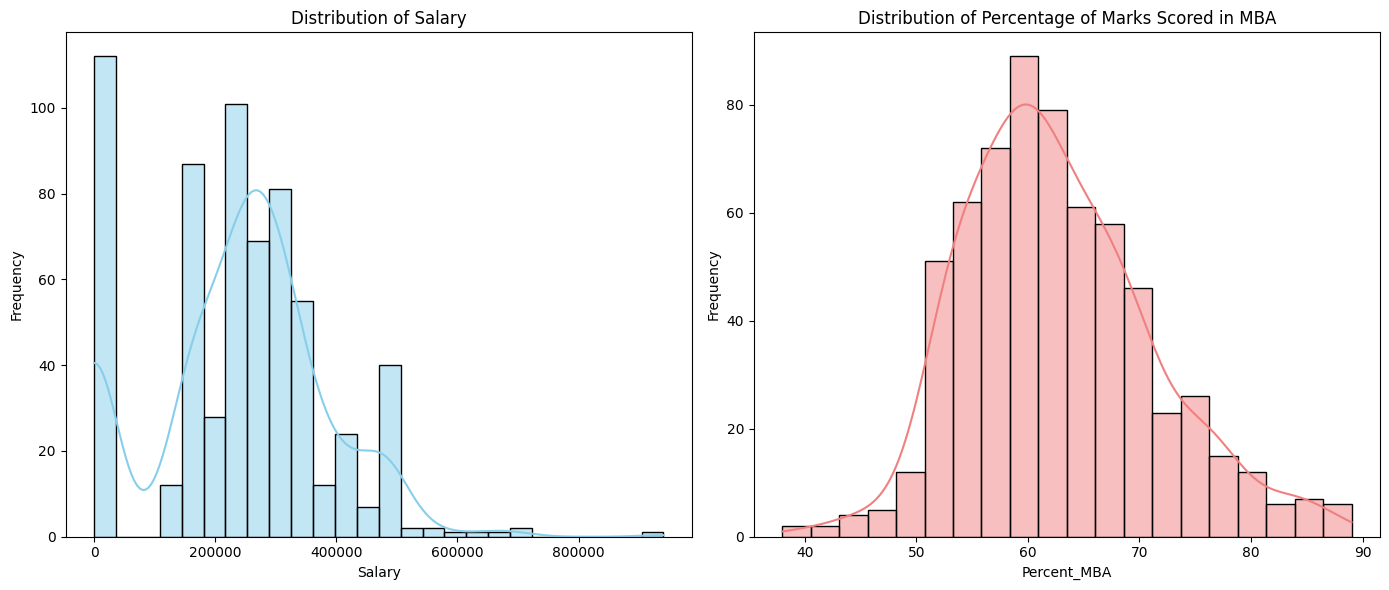


#### Skewness and Kurtosis for 'Salary' and 'Percent_MBA':

Salary:
  Skewness: 0.0973
  Kurtosis: 0.5285

Percent_MBA:
  Skewness: 0.5235
  Kurtosis: 0.3007

#### Interpretation:

**Skewness:**
  - A skewness value close to 0 indicates a symmetrical distribution.
  - Positive skewness indicates a tail on the right side (right-skewed). Mean > Median.
  - Negative skewness indicates a tail on the left side (left-skewed). Mean < Median.

**Kurtosis:**
  - Kurtosis measures the 'tailedness' of the distribution.
  - A kurtosis value close to 0 (for Fisher's kurtosis, which is standard in pandas) indicates a mesokurtic distribution, similar to a normal distribution.
  - Positive kurtosis (leptokurtic) indicates heavy tails or more outliers than a normal distribution.
  - Negative kurtosis (platykurtic) indicates light tails or fewer outliers than a normal distribution.

Based on these values and the histograms, we can describe the shape of the distributions for 'Salary' and 'Percent_MBA'.


In [23]:
print("#### Histograms for 'Salary' and 'Percent_MBA':")

plt.figure(figsize=(14, 6))

# Histogram for Salary
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Salary'], kde=True, color='skyblue')
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')

# Histogram for Percent_MBA
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df['Percent_MBA'], kde=True, color='lightcoral')
plt.title('Distribution of Percentage of Marks Scored in MBA')
plt.xlabel('Percent_MBA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n#### Skewness and Kurtosis for 'Salary' and 'Percent_MBA':")

skewness_salary = df['Salary'].skew()
kurtosis_salary = df['Salary'].kurtosis()

skewness_mba = df['Percent_MBA'].skew()
kurtosis_mba = df['Percent_MBA'].kurtosis()

print(f"\nSalary:")
print(f"  Skewness: {skewness_salary:.4f}")
print(f"  Kurtosis: {kurtosis_salary:.4f}")

print(f"\nPercent_MBA:")
print(f"  Skewness: {skewness_mba:.4f}")
print(f"  Kurtosis: {kurtosis_mba:.4f}")

print("\n#### Interpretation:\n")
print("**Skewness:**")
print("  - A skewness value close to 0 indicates a symmetrical distribution.")
print("  - Positive skewness indicates a tail on the right side (right-skewed). Mean > Median.")
print("  - Negative skewness indicates a tail on the left side (left-skewed). Mean < Median.")

print("\n**Kurtosis:**")
print("  - Kurtosis measures the 'tailedness' of the distribution.")
print("  - A kurtosis value close to 0 (for Fisher's kurtosis, which is standard in pandas) indicates a mesokurtic distribution, similar to a normal distribution.")
print("  - Positive kurtosis (leptokurtic) indicates heavy tails or more outliers than a normal distribution.")
print("  - Negative kurtosis (platykurtic) indicates light tails or fewer outliers than a normal distribution.")

print("\nBased on these values and the histograms, we can describe the shape of the distributions for 'Salary' and 'Percent_MBA'.")

### 4a.iii) Draw a boxplot for salary based on different MBA specialization, what do you observe in terms of outliers, and salary difference for specialization segments. (5 marks)



#### Boxplot of Salary based on MBA Specialization


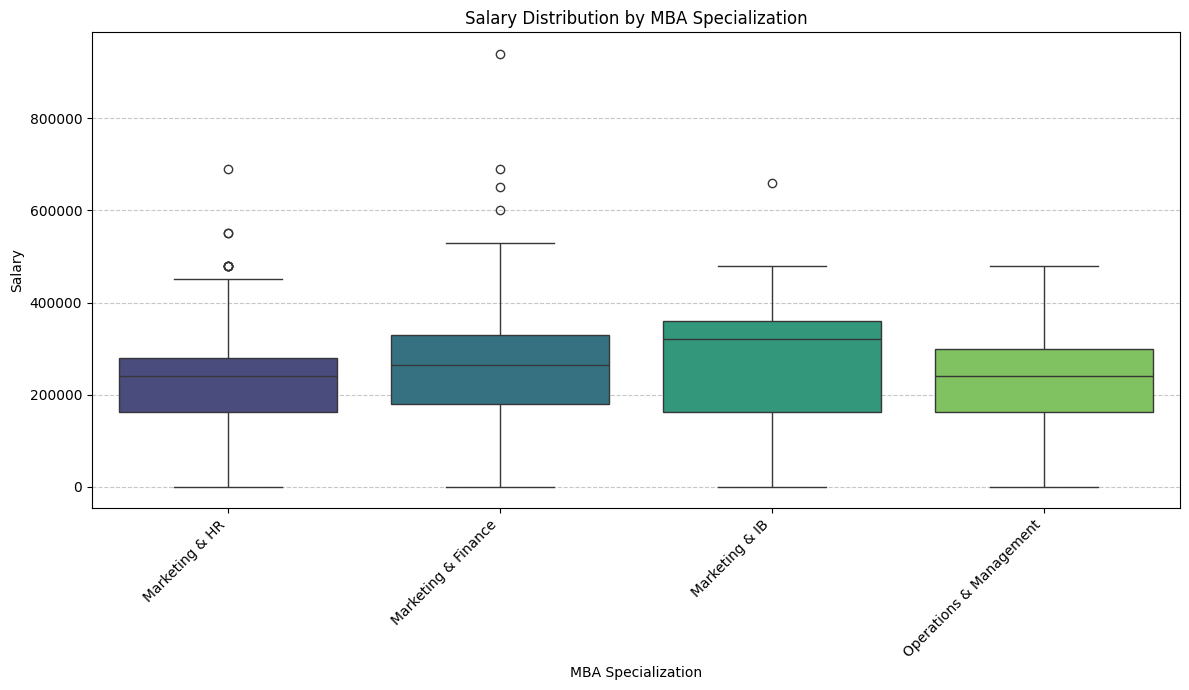


#### Observations and Conclusion:
Based on the boxplot:
  1. **Outliers:** Outliers are typically represented by individual points beyond the 'whiskers' of the boxplots. We can observe if there are any salaries that fall significantly outside the typical range for their respective MBA specialization.
  2. **Salary Difference for Specialization Segments:**
     - The 'box' represents the interquartile range (IQR), and the line inside the box is the median salary.
     - We can compare the median salaries (central line) and the spread of salaries (height of the box) across different specializations.
     - If the boxes are at different heights or their IQRs do not overlap significantly, it suggests a difference in the salary distributions between specializations.
     - The length of the whiskers indicates the range of data, excluding outliers. Shorter whiskers suggest less variability within the non-outlier data.

Further statistical tests (e.g., ANOVA) could be performed to formally d

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### Boxplot of Salary based on MBA Specialization")

plt.figure(figsize=(12, 7))
sns.boxplot(x='Specialization_MBA', y='Salary', data=df, palette='viridis')
plt.title('Salary Distribution by MBA Specialization')
plt.xlabel('MBA Specialization')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n#### Observations and Conclusion:")
print("Based on the boxplot:")
print("  1. **Outliers:** Outliers are typically represented by individual points beyond the 'whiskers' of the boxplots. We can observe if there are any salaries that fall significantly outside the typical range for their respective MBA specialization.")
print("  2. **Salary Difference for Specialization Segments:**")
print("     - The 'box' represents the interquartile range (IQR), and the line inside the box is the median salary.")
print("     - We can compare the median salaries (central line) and the spread of salaries (height of the box) across different specializations.")
print("     - If the boxes are at different heights or their IQRs do not overlap significantly, it suggests a difference in the salary distributions between specializations.")
print("     - The length of the whiskers indicates the range of data, excluding outliers. Shorter whiskers suggest less variability within the non-outlier data.")

print("\nFurther statistical tests (e.g., ANOVA) could be performed to formally determine if these observed differences are statistically significant.")

### 4a.iv) Draw a scatter plot for all of the variables, what is your observation and conclusion for the relationship between students salary and  the other numeric variables (5 marks)


#### Scatter Plots of Salary vs. Other Numeric Variables


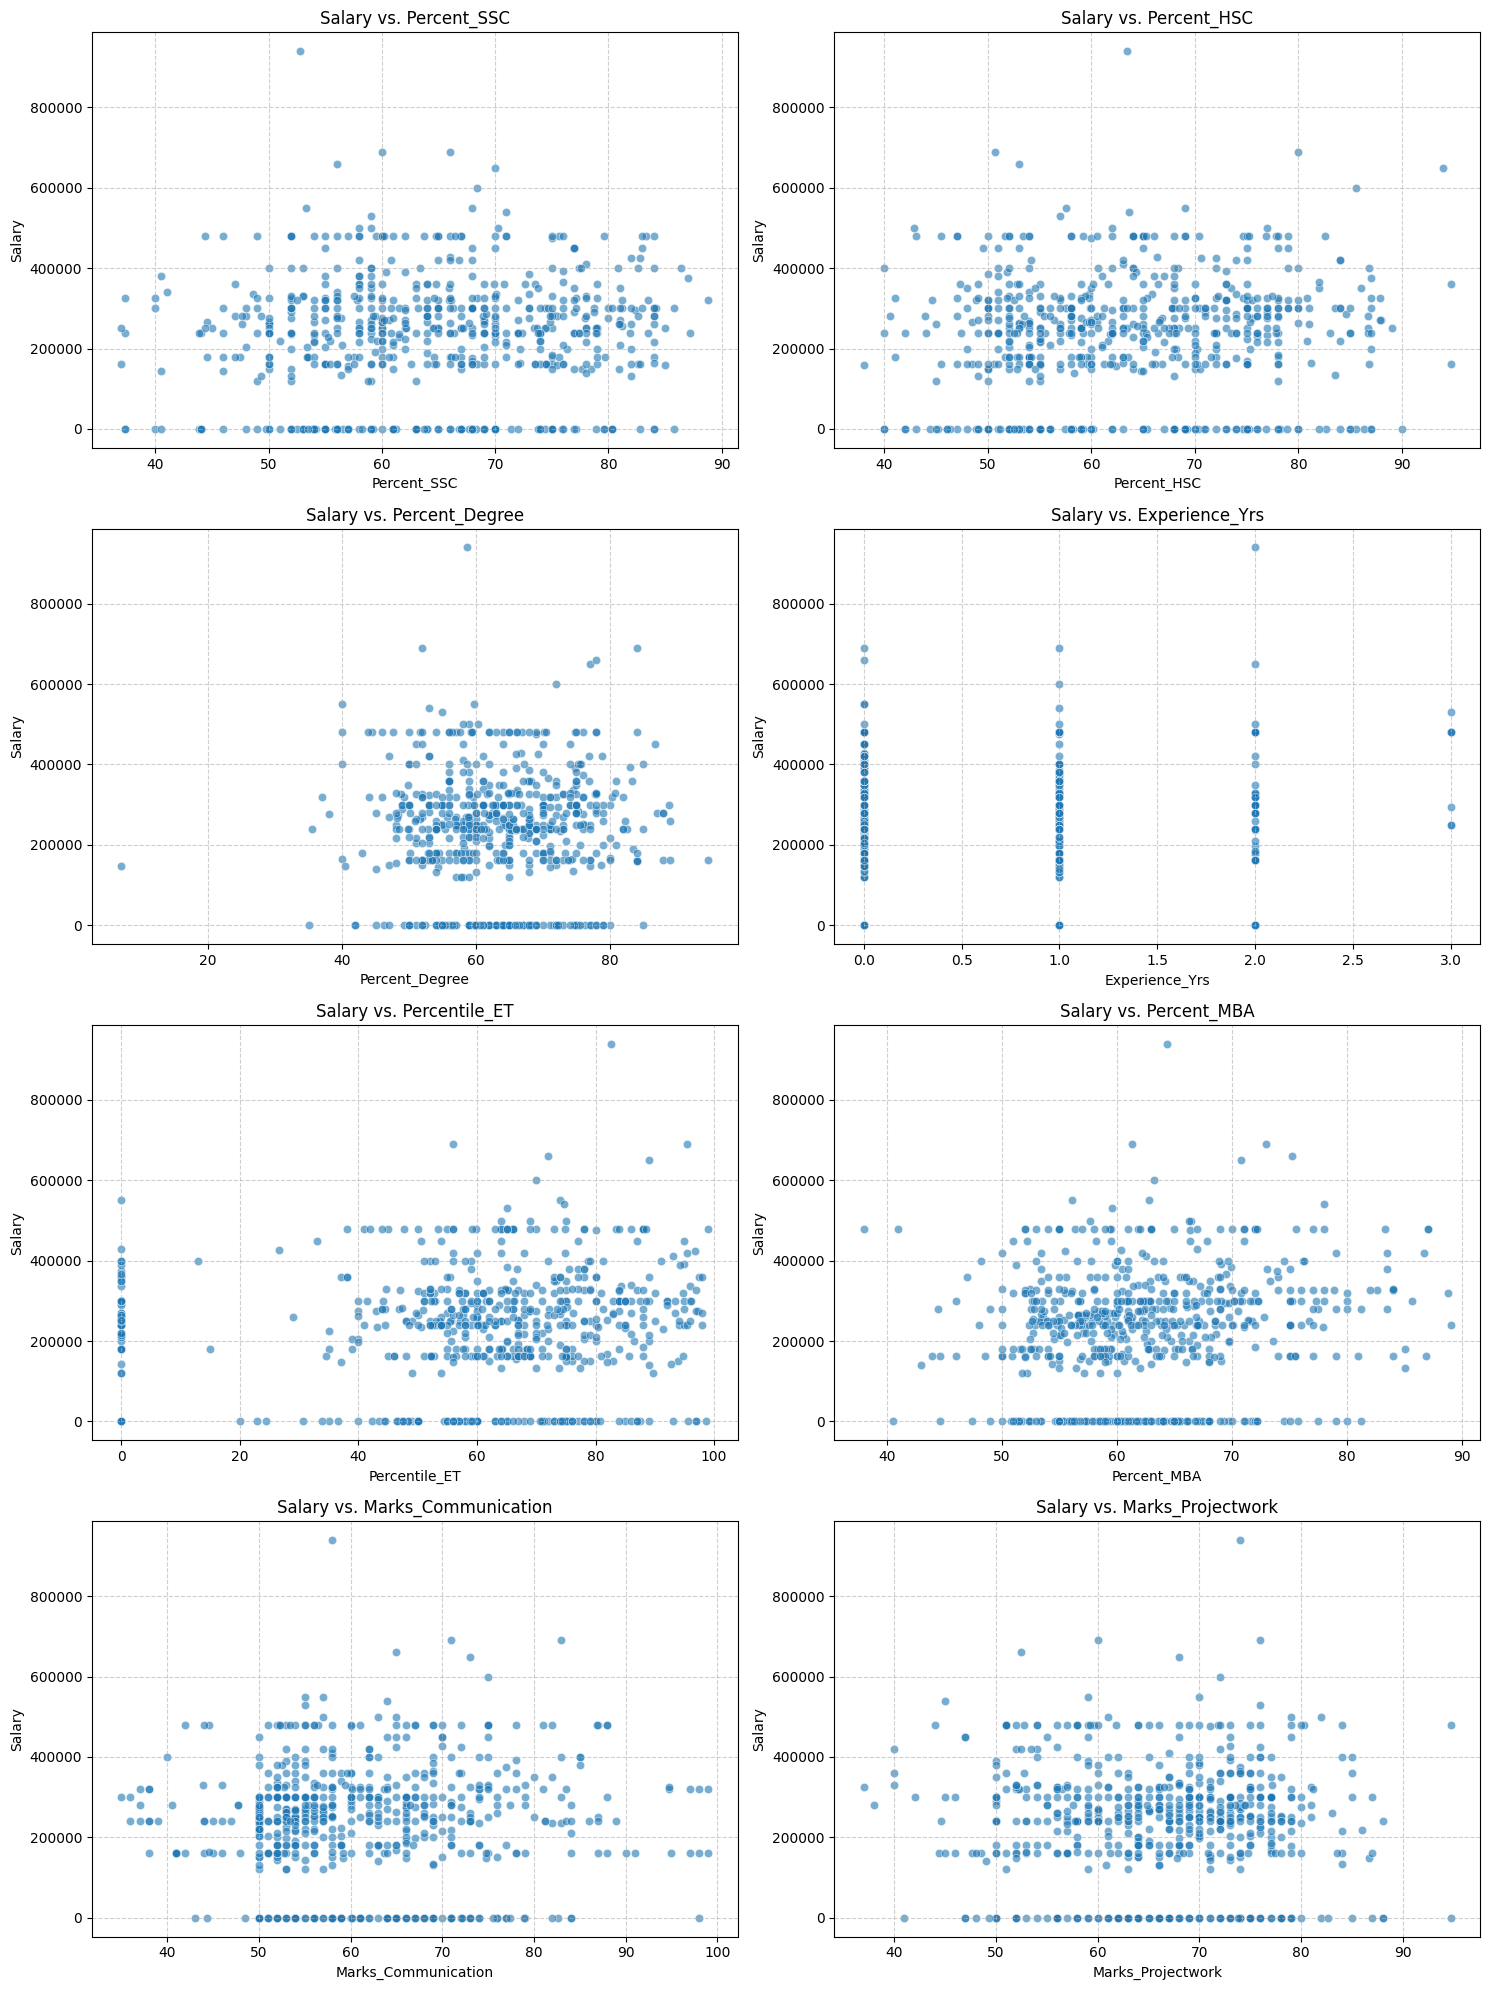


#### Observations and Conclusion:
Based on the scatter plots, we can observe the following:

**General Trends:**
  - **Positive Correlation:** If points generally go up from left to right, it suggests a positive relationship. As the independent variable increases, Salary tends to increase.
  - **Negative Correlation:** If points generally go down from left to right, it suggests a negative relationship. As the independent variable increases, Salary tends to decrease.
  - **No Apparent Correlation:** If points are scattered randomly with no clear pattern, it suggests little to no linear relationship between the variable and Salary.
**Strength of Relationship:**
  - **Strong:** Points cluster closely around an imaginary line.
  - **Weak:** Points are widely spread.
**Outliers:**
  - Individual points that deviate significantly from the overall pattern might be outliers and could influence the perceived relationship.
**Specific Variable Observations (example for some common variables):**


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### Scatter Plots of Salary vs. Other Numeric Variables")

# Identify numerical columns, excluding 'SlNo' and 'Salary' itself
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('SlNo') # SlNo is an identifier, not a variable for correlation
if 'Salary' in numerical_cols:
    numerical_cols.remove('Salary') # We are plotting against Salary, so remove it from the independent variable list

# Determine the number of plots needed
num_plots = len(numerical_cols)
num_rows = (num_plots + 1) // 2 # Arrange in 2 columns

plt.figure(figsize=(15, 5 * num_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['Salary'], alpha=0.6)
    plt.title(f'Salary vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Salary')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n#### Observations and Conclusion:")
print("Based on the scatter plots, we can observe the following:\n")

print("**General Trends:**")
print("  - **Positive Correlation:** If points generally go up from left to right, it suggests a positive relationship. As the independent variable increases, Salary tends to increase.")
print("  - **Negative Correlation:** If points generally go down from left to right, it suggests a negative relationship. As the independent variable increases, Salary tends to decrease.")
print("  - **No Apparent Correlation:** If points are scattered randomly with no clear pattern, it suggests little to no linear relationship between the variable and Salary.")

print("**Strength of Relationship:**")
print("  - **Strong:** Points cluster closely around an imaginary line.")
print("  - **Weak:** Points are widely spread.")

print("**Outliers:**")
print("  - Individual points that deviate significantly from the overall pattern might be outliers and could influence the perceived relationship.")

print("**Specific Variable Observations (example for some common variables):**")
print("  - **Percent_SSC, Percent_HSC, Percent_Degree, Percent_MBA:** Often, higher percentages in academics might correlate positively with higher salaries, but this is not always linear or strong. The plots will show if there's any visible trend.")
print("  - **Experience_Yrs:** Generally, more experience tends to correlate with higher salaries, which might be visible as a positive trend.")
print("  - **Percentile_ET:** Performance in entrance tests could show some positive relationship with salary.")

print("\n**To draw definitive conclusions about the strength and direction of these relationships, it would be beneficial to calculate Pearson correlation coefficients for each numerical variable with Salary. These plots provide a visual preliminary assessment.**")

### 4b. Consider the admission.csv file and answer the following questions

### 4b.i)  Check whether the percentile in entrance test from the data follows normal distribution by using a proper plot and with suitable statistical test. (5 marks)

#### Normality Check for 'Percentile_ET'



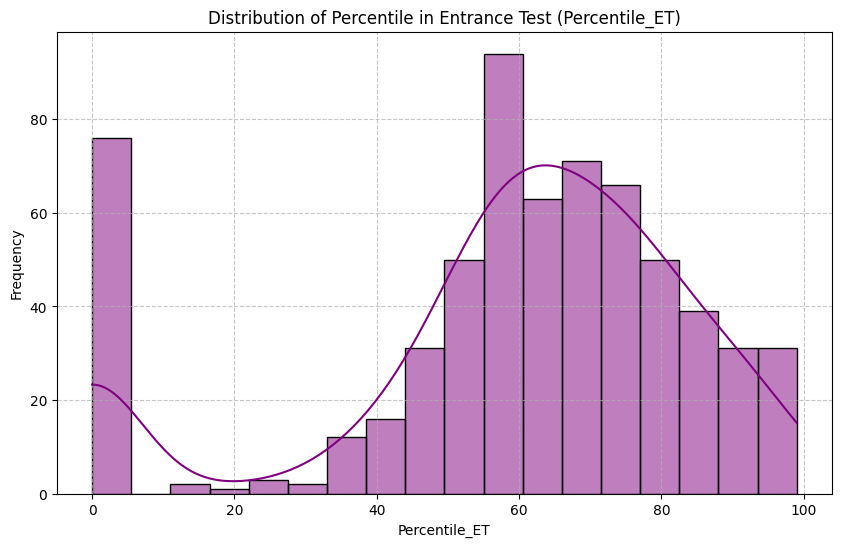


**Visual Observation:**
Based on the histogram with the Kernel Density Estimate (KDE) curve, we can visually assess the shape of the distribution. A bell-shaped, symmetrical curve would suggest normality. Deviations from this shape (skewness, unusual peaks/tails) would indicate non-normality.

#### Shapiro-Wilk Test for Normality
Shapiro-Wilk Test Statistic: 0.8737
P-value: 0.0000

**Conclusion from Shapiro-Wilk Test:**
Since the p-value (0.0000) is less than or equal to the significance level (0.05), we reject the null hypothesis.
Therefore, there is sufficient evidence to conclude that 'Percentile_ET' is not normally distributed.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

# Load the admission data if not already loaded
df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### Normality Check for 'Percentile_ET'\n")

# --- Visual Check: Histogram with KDE ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Percentile_ET'], kde=True, color='purple')
plt.title('Distribution of Percentile in Entrance Test (Percentile_ET)')
plt.xlabel('Percentile_ET')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n**Visual Observation:**\nBased on the histogram with the Kernel Density Estimate (KDE) curve, we can visually assess the shape of the distribution. A bell-shaped, symmetrical curve would suggest normality. Deviations from this shape (skewness, unusual peaks/tails) would indicate non-normality.")

# --- Statistical Test: Shapiro-Wilk Test ---
print("\n#### Shapiro-Wilk Test for Normality")
# H0: The data is normally distributed.
# H1: The data is not normally distributed.

stat, p_value = shapiro(df['Percentile_ET'])

significance_level = 0.05

print(f"Shapiro-Wilk Test Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

print("\n**Conclusion from Shapiro-Wilk Test:**")
if p_value > significance_level:
    print(f"Since the p-value ({p_value:.4f}) is greater than the significance level ({significance_level}), we fail to reject the null hypothesis.")
    print("Therefore, there is not enough evidence to conclude that 'Percentile_ET' is not normally distributed. We can assume it follows a normal distribution.")
else:
    print(f"Since the p-value ({p_value:.4f}) is less than or equal to the significance level ({significance_level}), we reject the null hypothesis.")
    print("Therefore, there is sufficient evidence to conclude that 'Percentile_ET' is not normally distributed.")

### 4b.ii)Conduct a hypothesis to see whether there is a difference in terms of salary for students degree specialization of management and engineering. What do you conclude (consider level of significance 0.05) (5 marks)

#### 4b.ii) Hypothesis Test for Salary Difference between Degree Specializations (Management vs. Engineering)

**1. Hypotheses:**
Null Hypothesis (H0): There is no significant difference in the mean salary between students with Management and Engineering degree specializations. (μ_Management = μ_Engineering)
Alternative Hypothesis (H1): There is a significant difference in the mean salary between students with Management and Engineering degree specializations. (μ_Management ≠ μ_Engineering)
This is a two-tailed test.

Sample size for Management: 252
Mean Salary for Management: 213145.24
Std Dev Salary for Management: 130232.24

Sample size for Engineering: 140
Mean Salary for Engineering: 276328.57
Std Dev Salary for Engineering: 165157.63

**2. Test Results (Two-Sample Independent t-test):**
T-statistic: -3.9024
P-value: 0.0001
Significance Level (alpha): 0.05

**3. Conclusion:**
Since the p-value (0.0001) is less than the significance level (0.05), we reject the null hypothesis.
Ther

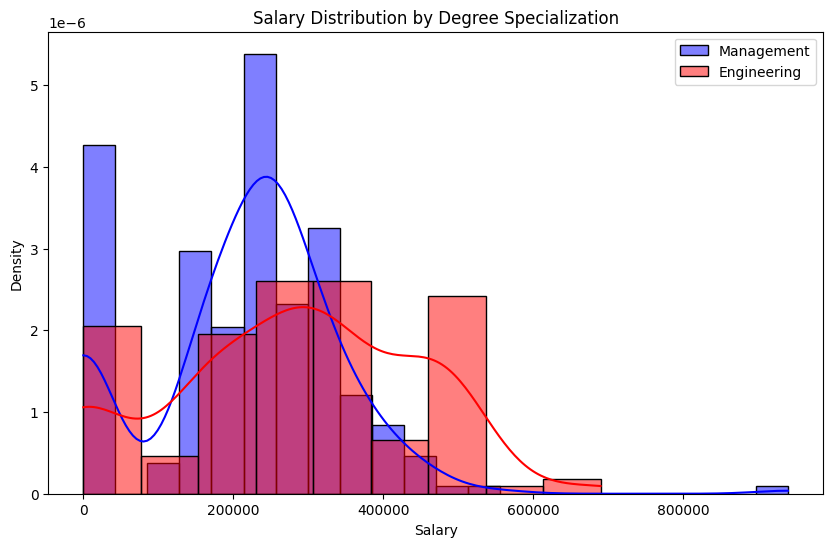

In [27]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the admission data if not already loaded
df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### 4b.ii) Hypothesis Test for Salary Difference between Degree Specializations (Management vs. Engineering)\n")

# --- 1. Define Hypotheses ---
print("**1. Hypotheses:**")
print("Null Hypothesis (H0): There is no significant difference in the mean salary between students with Management and Engineering degree specializations. (μ_Management = μ_Engineering)")
print("Alternative Hypothesis (H1): There is a significant difference in the mean salary between students with Management and Engineering degree specializations. (μ_Management ≠ μ_Engineering)")
print("This is a two-tailed test.")

# --- 2. Data Preparation ---
# Filter data for Management and Engineering specializations
salary_management = df[df['Course_Degree'] == 'Management']['Salary'].dropna()
salary_engineering = df[df['Course_Degree'] == 'Engineering']['Salary'].dropna()

print(f"\nSample size for Management: {len(salary_management)}")
print(f"Mean Salary for Management: {salary_management.mean():.2f}")
print(f"Std Dev Salary for Management: {salary_management.std():.2f}")

print(f"\nSample size for Engineering: {len(salary_engineering)}")
print(f"Mean Salary for Engineering: {salary_engineering.mean():.2f}")
print(f"Std Dev Salary for Engineering: {salary_engineering.std():.2f}")

# --- 3. Perform the Test ---
# Type of Test: Two-Sample Independent t-test.
# We assume unequal variances (Welch's t-test) which is generally more robust when variance equality is not confirmed.
alpha = 0.05 # Significance level

t_statistic, p_value = stats.ttest_ind(salary_management, salary_engineering, equal_var=False) # equal_var=False for Welch's t-test

print(f"\n**2. Test Results (Two-Sample Independent t-test):**")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance Level (alpha): {alpha}")

# --- 4. Conclusion ---
print("\n**3. Conclusion:**")
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Therefore, there is sufficient statistical evidence to conclude that there is a significant difference in the mean salary between students with Management and Engineering degree specializations.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Therefore, there is not enough statistical evidence to conclude that there is a significant difference in the mean salary between students with Management and Engineering degree specializations.")

# Optional: Visualize the distributions
plt.figure(figsize=(10, 6))
sns.histplot(salary_management, color='blue', label='Management', kde=True, stat='density', alpha=0.5)
sns.histplot(salary_engineering, color='red', label='Engineering', kde=True, stat='density', alpha=0.5)
plt.title('Salary Distribution by Degree Specialization')
plt.xlabel('Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

### 4b.iii)Conduct an hypothesis to prove whether the salary of a student from commenrce stream is higher than Science stream, do you agree or not. (consider level of significance 0.05)  (5 marks)

#### 4b.iii) Hypothesis Test for Salary Difference between Commerce and Science Streams

**1. Hypotheses:**
Null Hypothesis (H0): The mean salary of students from the Commerce stream is less than or equal to the mean salary of students from the Science stream. (μ_Commerce <= μ_Science)
Alternative Hypothesis (H1): The mean salary of students from the Commerce stream is higher than the mean salary of students from the Science stream. (μ_Commerce > μ_Science)
This is a one-tailed (right-tailed) test.

Sample size for Commerce (Placed): 231
Mean Salary for Commerce (Placed): 297773.16
Std Dev Salary for Commerce (Placed): 109013.57

Sample size for Science (Placed): 175
Mean Salary for Science (Placed): 283411.43
Std Dev Salary for Science (Placed): 94092.59

**2. Test Results (Two-Sample Independent t-test - Welch's):**
T-statistic: 1.4218
One-tailed P-value: 0.0779
Significance Level (alpha): 0.05

**3. Conclusion:**
Since the one-tailed p-value (0.0779) is greater than or equal to the 

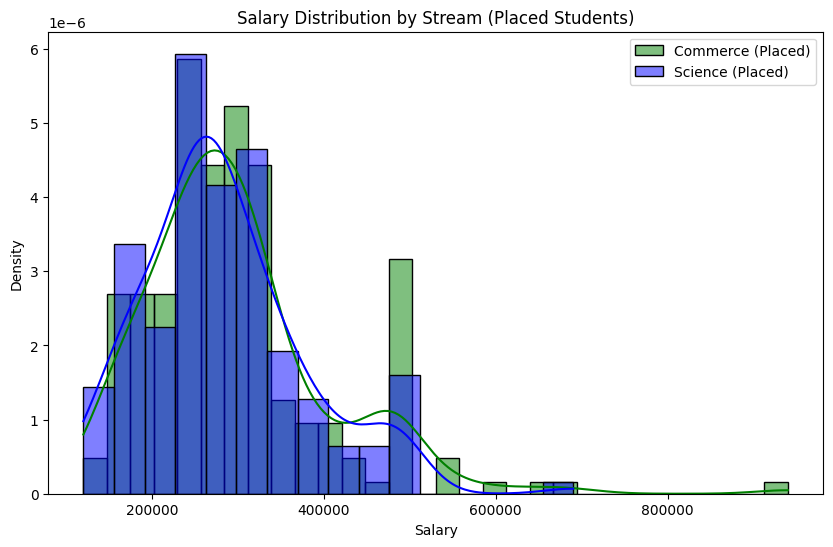

In [28]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the admission data if not already loaded
df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### 4b.iii) Hypothesis Test for Salary Difference between Commerce and Science Streams\n")

# --- 1. Define Hypotheses ---
print("**1. Hypotheses:**")
print("Null Hypothesis (H0): The mean salary of students from the Commerce stream is less than or equal to the mean salary of students from the Science stream. (μ_Commerce <= μ_Science)")
print("Alternative Hypothesis (H1): The mean salary of students from the Commerce stream is higher than the mean salary of students from the Science stream. (μ_Commerce > μ_Science)")
print("This is a one-tailed (right-tailed) test.")

# --- 2. Data Preparation ---
# Filter data for Commerce and Science streams, only considering 'Placed' students for salary comparison
salary_commerce = df[(df['Stream_HSC'] == 'Commerce') & (df['Placement'] == 'Placed')]['Salary'].dropna()
salary_science = df[(df['Stream_HSC'] == 'Science') & (df['Placement'] == 'Placed')]['Salary'].dropna()

print(f"\nSample size for Commerce (Placed): {len(salary_commerce)}")
print(f"Mean Salary for Commerce (Placed): {salary_commerce.mean():.2f}")
print(f"Std Dev Salary for Commerce (Placed): {salary_commerce.std():.2f}")

print(f"\nSample size for Science (Placed): {len(salary_science)}")
print(f"Mean Salary for Science (Placed): {salary_science.mean():.2f}")
print(f"Std Dev Salary for Science (Placed): {salary_science.std():.2f}")

# --- 3. Perform the Test ---
# Type of Test: Two-Sample Independent t-test (assuming unequal variances - Welch's t-test)
alpha = 0.05 # Significance level

t_statistic, p_value_two_tailed = stats.ttest_ind(salary_commerce, salary_science, equal_var=False) # equal_var=False for Welch's t-test

# For a right-tailed test, if t_statistic is positive, p_value_one_tailed = p_value_two_tailed / 2
# If t_statistic is negative, it means mean_commerce < mean_science, so p-value would be > 0.5 (fail to reject H0)
if t_statistic > 0:
    p_value_one_tailed = p_value_two_tailed / 2
else:
    p_value_one_tailed = 1 - (p_value_two_tailed / 2) # Highly unlikely to be useful if t_statistic is negative

print(f"\n**2. Test Results (Two-Sample Independent t-test - Welch's):**")
print(f"T-statistic: {t_statistic:.4f}")
print(f"One-tailed P-value: {p_value_one_tailed:.4f}")
print(f"Significance Level (alpha): {alpha}")

# --- 4. Conclusion ---
print("\n**3. Conclusion:**")
if p_value_one_tailed < alpha:
    print(f"Since the one-tailed p-value ({p_value_one_tailed:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Therefore, there is sufficient statistical evidence to conclude that the mean salary of students from the Commerce stream is higher than that of students from the Science stream.")
else:
    print(f"Since the one-tailed p-value ({p_value_one_tailed:.4f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Therefore, there is not enough statistical evidence to conclude that the mean salary of students from the Commerce stream is higher than that of students from the Science stream. We agree with the Null Hypothesis.")

# Optional: Visualize the distributions
plt.figure(figsize=(10, 6))
sns.histplot(salary_commerce, color='green', label='Commerce (Placed)', kde=True, stat='density', alpha=0.5)
sns.histplot(salary_science, color='blue', label='Science (Placed)', kde=True, stat='density', alpha=0.5)
plt.title('Salary Distribution by Stream (Placed Students)')
plt.xlabel('Salary')
plt.ylabel('Density')
plt.legend()
plt.show()



### 4b.iv)Conduct an ANOVA to check whether there is salary difference for students with diffetent MBA_specialization of Marketing & Finance , Marketing & HR, Operations & Management, Marketing & IB. State your inferences. (consider level of significance 0.05)  (5 marks)






#### 4b.iv) ANOVA for Salary Difference across MBA Specializations

**1. Hypotheses:**
Null Hypothesis (H0): There is no significant difference in the mean salary among students across the specified MBA specializations. (μ_Marketing&Finance = μ_Marketing&HR = μ_Operations&Management = μ_Marketing&IB)
Alternative Hypothesis (H1): At least one of the mean salaries among the specified MBA specializations is different.
This is an Omnibus test.

Sample size for Marketing & Finance: 222
Mean Salary for Marketing & Finance: 308504.50
Std Dev Salary for Marketing & Finance: 108983.28

Sample size for Marketing & HR: 144
Mean Salary for Marketing & HR: 264726.39
Std Dev Salary for Marketing & HR: 90935.69

Sample size for Operations & Management: 75
Mean Salary for Operations & Management: 249946.67
Std Dev Salary for Operations & Management: 81830.39

Sample size for Marketing & IB: 72
Mean Salary for Marketing & IB: 317875.00
Std Dev Salary for Marketing & IB: 109211.25

**2. Test Results (On

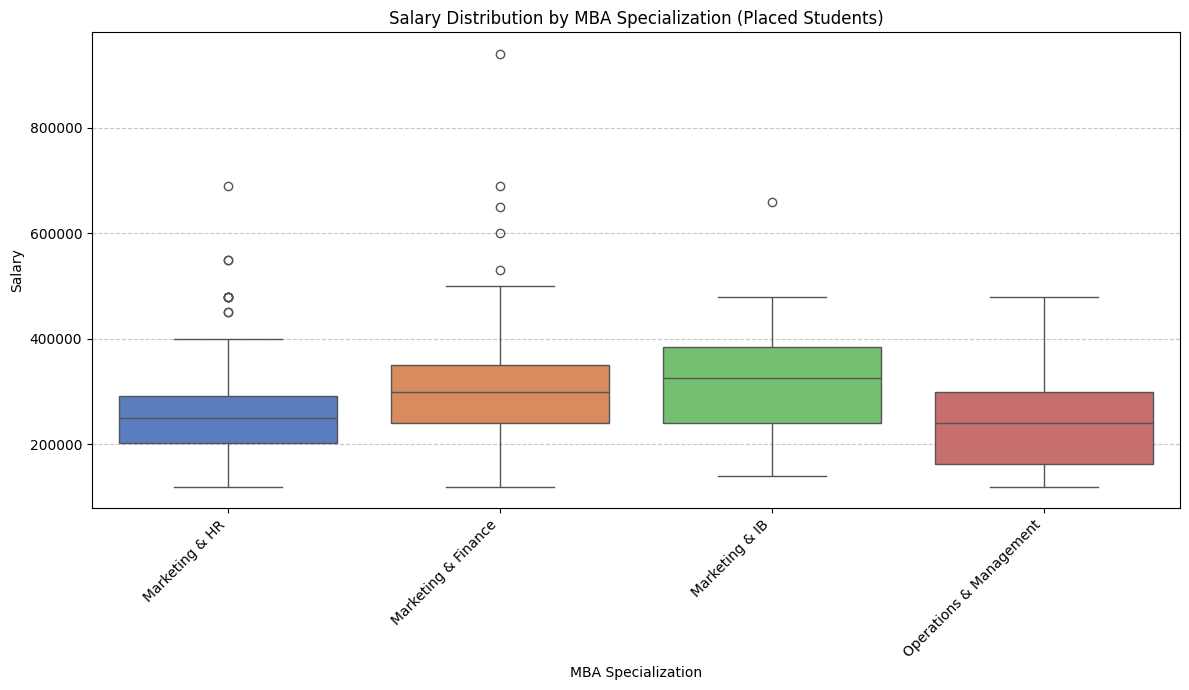

In [29]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the admission data if not already loaded
df = pd.read_excel('/content/sample_data/admission.xlsx')

print("#### 4b.iv) ANOVA for Salary Difference across MBA Specializations\n")

# --- 1. Define Hypotheses ---
print("**1. Hypotheses:**")
print("Null Hypothesis (H0): There is no significant difference in the mean salary among students across the specified MBA specializations. (μ_Marketing&Finance = μ_Marketing&HR = μ_Operations&Management = μ_Marketing&IB)")
print("Alternative Hypothesis (H1): At least one of the mean salaries among the specified MBA specializations is different.")
print("This is an Omnibus test.")

# --- 2. Data Preparation ---
# Define the specializations to compare
specializations = ['Marketing & Finance', 'Marketing & HR', 'Operations & Management', 'Marketing & IB']

# Filter the DataFrame to include only these specializations and placed students
df_filtered = df[(df['Specialization_MBA'].isin(specializations)) & (df['Placement'] == 'Placed')].copy()

# Extract salaries for each group
salary_groups = []
for spec in specializations:
    salaries = df_filtered[df_filtered['Specialization_MBA'] == spec]['Salary'].dropna()
    salary_groups.append(salaries)
    print(f"\nSample size for {spec}: {len(salaries)}")
    print(f"Mean Salary for {spec}: {salaries.mean():.2f}")
    print(f"Std Dev Salary for {spec}: {salaries.std():.2f}")

# --- 3. Perform the Test ---
# Type of Test: One-way ANOVA
alpha = 0.05 # Significance level

# Perform the one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*salary_groups)

print(f"\n**2. Test Results (One-way ANOVA):**")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance Level (alpha): {alpha}")

# --- 4. Conclusion ---
print("\n**3. Conclusion:**")
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Therefore, there is sufficient statistical evidence to conclude that there is a significant difference in the mean salary among students with different MBA specializations (Marketing & Finance, Marketing & HR, Operations & Management, Marketing & IB).")
    print("To identify which specific groups differ, a post-hoc test (e.g., Tukey's HSD) would be required.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Therefore, there is not enough statistical evidence to conclude that there is a significant difference in the mean salary among students with different MBA specializations.")
    print("We infer that the mean salaries for these MBA specializations are not significantly different.")

# Optional: Visualize the distributions with boxplots
plt.figure(figsize=(12, 7))
sns.boxplot(x='Specialization_MBA', y='Salary', data=df_filtered, palette='muted')
plt.title('Salary Distribution by MBA Specialization (Placed Students)')
plt.xlabel('MBA Specialization')
plt.ylabel('Salary')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()